# Experiment 4c v4 — DOMINANT / CoLA vs AISO-SSL

## 핵심 질문
Graph SSL (DOMINANT, CoLA) 방법들은 메시지 패싱으로 이웃을 활용하는데,
이웃에 illicit 노드가 섞여 있을 때 이 "이웃 오염(neighborhood contamination)"이 성능에 어떤 영향을 미치는가?
AISO의 노드 레벨 표현은 이 오염에서 자유로운가?


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy.sparse as sp
from scipy.sparse import csr_matrix
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler as MMS, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt, warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE   = r'c:\Users\kevin\OneDrive\Desktop\AISO\Elliptic Bitcoin\elliptic_bitcoin_dataset'
SEED   = 42

feat_df = pd.read_csv(f'{BASE}/elliptic_txs_features.csv', header=None)
cls_df  = pd.read_csv(f'{BASE}/elliptic_txs_classes.csv')
edge_df = pd.read_csv(f'{BASE}/elliptic_txs_edgelist.csv')
feat_df.columns = ['txId'] + [f'f{i}' for i in range(1,167)]
feat_df['timestep'] = feat_df['f1'].astype(int)
df = feat_df.merge(cls_df, on='txId')
labeled = df[df['class'] != 'unknown'].copy().reset_index(drop=True)
labeled['y'] = (labeled['class'] == '1').astype(int)
feat_cols = [f'f{i}' for i in range(1,167)]
X_all    = labeled[feat_cols].values.astype(float)
y_all    = labeled['y'].values
ts_all   = labeled['timestep'].values
N_NODES  = len(labeled)
X_scaled = StandardScaler().fit_transform(X_all)

txid_map = {tid: i for i, tid in enumerate(labeled['txId'].values)}
src_list, dst_list = [], []
for _, row in edge_df.iterrows():
    s, d = txid_map.get(row['txId1']), txid_map.get(row['txId2'])
    if s is not None and d is not None:
        src_list.append(s); dst_list.append(d)
src_arr = np.array(src_list); dst_arr = np.array(dst_list)

train_mask        = ts_all <= 34; test_mask = ts_all > 34
train_licit_idx   = np.where(train_mask & (y_all==0))[0]
test_idx          = np.where(test_mask)[0]
y_te = y_all[test_idx]
test_idx_set      = set(test_idx.tolist())

# Dom-8 피처
src_bi = np.concatenate([src_arr, dst_arr])
node_degree = np.bincount(src_bi, minlength=N_NODES).astype(float)
ts_norm = (ts_all-ts_all.min()) / max(ts_all.max()-ts_all.min(), 1)
lf = X_scaled[:,1:94]; af = X_scaled[:,94:166]
dom8 = MMS().fit_transform(np.stack([
    node_degree,
    lf.mean(1), lf.std(1), lf.max(1),
    af.mean(1), af.std(1), af.max(1),
    ts_norm,
], axis=1))

rng_licit  = np.random.RandomState(SEED)
licit_samp = rng_licit.choice(train_licit_idx, 3000, replace=False)
licit_samp_set = set(licit_samp.tolist())
X_licit = dom8[licit_samp]
X_te    = dom8[test_idx]

print(f"N_NODES={N_NODES}  licit_train={len(licit_samp)}  test={len(test_idx)}")
print(f"test illicit={y_te.sum()}  비율={y_te.mean():.4f}")
print(f"Dom-8: {dom8.shape}")


N_NODES=46564  licit_train=3000  test=16670
test illicit=1083  비율=0.0650
Dom-8: (46564, 8)


In [2]:
# 이웃 오염 측정: licit/illicit 노드의 이웃 중 illicit 비율
neigh_illicit_ratio = {}
adj_dict = {}  # node -> set of neighbors (all labeled)

for s, d in zip(src_arr, dst_arr):
    adj_dict.setdefault(s, set()).add(d)
    adj_dict.setdefault(d, set()).add(s)

licit_contamination, illicit_neigh_ratio = [], []
for idx in test_idx:
    nbrs = adj_dict.get(idx, set())
    if len(nbrs) == 0: continue
    nbr_labels = [y_all[n] for n in nbrs if n < N_NODES]
    if len(nbr_labels) == 0: continue
    ratio = np.mean(nbr_labels)
    if y_all[idx] == 0:
        licit_contamination.append(ratio)  # licit 테스트 노드의 illicit 이웃 비율
    else:
        illicit_neigh_ratio.append(ratio)  # illicit 테스트 노드의 illicit 이웃 비율

print("=== 이웃 오염 분석 (테스트 셋) ===")
print(f"Licit 테스트 노드의 illicit 이웃 비율:  mean={np.mean(licit_contamination):.4f}  max={np.max(licit_contamination):.4f}")
print(f"Illicit 테스트 노드의 illicit 이웃 비율: mean={np.mean(illicit_neigh_ratio):.4f}  max={np.max(illicit_neigh_ratio):.4f}")
print(f"\n→ 메시지 패싱을 쓰면 licit 노드도 illicit 이웃 신호를 {np.mean(licit_contamination)*100:.1f}% 흡수함")
print(f"→ AISO는 이 오염에 무관: 노드 레벨 피처만 사용")


=== 이웃 오염 분석 (테스트 셋) ===
Licit 테스트 노드의 illicit 이웃 비율:  mean=0.0118  max=1.0000
Illicit 테스트 노드의 illicit 이웃 비율: mean=0.3795  max=1.0000

→ 메시지 패싱을 쓰면 licit 노드도 illicit 이웃 신호를 1.2% 흡수함
→ AISO는 이 오염에 무관: 노드 레벨 피처만 사용


In [3]:
def build_norm_adj(src_arr, dst_arr, n):
    rows = np.concatenate([src_arr, dst_arr])
    cols = np.concatenate([dst_arr, src_arr])
    data = np.ones(len(rows))
    adj = csr_matrix((data, (rows, cols)), shape=(n, n))
    adj = (adj > 0).astype(float)
    adj = adj + sp.eye(n)
    deg = np.array(adj.sum(1)).flatten()
    d_inv_sqrt = np.power(np.maximum(deg, 1e-10), -0.5)
    D = sp.diags(d_inv_sqrt)
    return (D @ adj @ D).tocsr()

def sp_to_torch(sp_mat):
    coo = sp_mat.tocoo()
    indices = torch.LongTensor(np.stack([coo.row, coo.col]))
    values  = torch.FloatTensor(coo.data)
    return torch.sparse_coo_tensor(indices, values, sp_mat.shape)

print("정규화 adjacency 빌드 중...")
A_norm = build_norm_adj(src_arr, dst_arr, N_NODES)
A_sp   = sp_to_torch(A_norm)
print(f"Adjacency: {A_norm.shape}  nnz={A_norm.nnz:,}")


정규화 adjacency 빌드 중...
Adjacency: (46564, 46564)  nnz=119,812


## DOMINANT (Graph Autoencoder, AAAI 2019)

GCN 인코더 + 속성 재구성 디코더.
표준 DOMINANT는 구조 재구성 + 속성 재구성이나,
전체 그래프 (46K 노드)에서 구조 재구성은 O(n²) 메모리를 요구하므로
속성 재구성만 사용 (Graph-AE).

**학습**: licit 노드 손실만 역전파
**추론**: 전체 그래프 GCN (이웃 오염 그대로 노출)
**점수**: 속성 재구성 오차


In [4]:
class GraphAE(nn.Module):
    """DOMINANT 스타일: GCN 인코더 + MLP 속성 디코더"""
    def __init__(self, in_dim, hid=32, z_dim=16):
        super().__init__()
        self.W1 = nn.Linear(in_dim, hid, bias=False)
        self.W2 = nn.Linear(hid, z_dim, bias=False)
        self.dec = nn.Sequential(
            nn.Linear(z_dim, hid), nn.ReLU(), nn.Linear(hid, in_dim)
        )

    def encode(self, A_sp, X):
        H = torch.relu(torch.sparse.mm(A_sp, self.W1(X)))
        Z = torch.relu(torch.sparse.mm(A_sp, self.W2(H)))
        return Z

    def forward(self, A_sp, X):
        Z  = self.encode(A_sp, X)
        return self.dec(Z), Z

torch.manual_seed(SEED)
X_all_t  = torch.tensor(dom8, dtype=torch.float32)
licit_mask = torch.zeros(N_NODES, dtype=torch.bool)
licit_mask[licit_samp] = True

model_dom = GraphAE(8, hid=32, z_dim=16)
opt_dom   = torch.optim.Adam(model_dom.parameters(), lr=1e-3)

print("DOMINANT 학습 중 (licit 손실만, full graph GCN)...")
for ep in range(300):
    model_dom.train(); opt_dom.zero_grad()
    X_hat, _ = model_dom(A_sp, X_all_t)
    loss = F.mse_loss(X_hat[licit_mask], X_all_t[licit_mask])
    loss.backward(); opt_dom.step()
    if (ep+1) % 100 == 0:
        print(f"  epoch {ep+1}: loss={loss.item():.5f}")

model_dom.eval()
with torch.no_grad():
    X_hat_all, _ = model_dom(A_sp, X_all_t)
    dominant_sc_all = torch.mean((X_all_t - X_hat_all)**2, dim=1).numpy()
dominant_sc = dominant_sc_all[test_idx]
print(f"\nDOMINANT 완료  score range: [{dominant_sc.min():.4f}, {dominant_sc.max():.4f}]")


DOMINANT 학습 중 (licit 손실만, full graph GCN)...


  epoch 100: loss=0.00197


  epoch 200: loss=0.00070


  epoch 300: loss=0.00052

DOMINANT 완료  score range: [0.0001, 0.2703]


## CoLA-simplified (Contrastive Learning on Attributed Networks, 2021)

CoLA 핵심 아이디어: 노드와 그 이웃의 표현이 유사해야 함 (positive pair).
다른 노드의 이웃과는 달라야 함 (negative pair).

**Anomaly score** = 노드 표현과 자신의 이웃 표현 간의 비유사도.
정상 노드: 이웃과 유사 → 낮은 score.
이상 노드: 이웃과 다름 → 높은 score.

**이웃 오염 효과**: licit 이상 노드의 이웃에 illicit이 섞이면
false positive 발생 가능.


In [5]:
# 이웃 평균 피처 계산 (전체 그래프 사용 → 오염 그대로)
neigh_mean_full = np.zeros_like(dom8)
neigh_cnt_full  = np.zeros(N_NODES)
for s, d in zip(src_arr, dst_arr):
    neigh_mean_full[d] += dom8[s]; neigh_cnt_full[d] += 1
    neigh_mean_full[s] += dom8[d]; neigh_cnt_full[s] += 1
mask_full = neigh_cnt_full > 0
neigh_mean_full[mask_full]  /= neigh_cnt_full[mask_full, None]
neigh_mean_full[~mask_full]  = dom8[~mask_full]

# CoLA 모델: f(node), g(neighborhood)
class CoLA_Net(nn.Module):
    def __init__(self, in_dim=8, hid=32, z_dim=16):
        super().__init__()
        self.f = nn.Sequential(nn.Linear(in_dim, hid), nn.ReLU(), nn.Linear(hid, z_dim))
        self.g = nn.Sequential(nn.Linear(in_dim, hid), nn.ReLU(), nn.Linear(hid, z_dim))

    def forward(self, x, x_neigh):
        return F.normalize(self.f(x), dim=-1), F.normalize(self.g(x_neigh), dim=-1)

def train_cola(X_licit, X_licit_neigh, epochs=200, temp=0.1, lr=1e-3, batch=256):
    torch.manual_seed(SEED)
    rng = np.random.RandomState(SEED)
    model = CoLA_Net(X_licit.shape[1])
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    n = len(X_licit)
    for ep in range(epochs):
        idx  = rng.choice(n, min(batch, n), replace=False)
        xb   = torch.tensor(X_licit[idx],       dtype=torch.float32)
        xnb  = torch.tensor(X_licit_neigh[idx], dtype=torch.float32)
        model.train(); opt.zero_grad()
        z, zn = model(xb, xnb)
        sim   = z @ zn.T / temp        # (batch, batch)
        labels = torch.arange(len(z))
        loss  = F.cross_entropy(sim, labels)
        loss.backward(); opt.step()
    return model

X_licit_neigh_full = neigh_mean_full[licit_samp]
print("CoLA 학습 중 (full graph 이웃, 오염 그대로)...")
model_cola = train_cola(X_licit, X_licit_neigh_full, epochs=300)

# 테스트 노드 점수: -sim(f(x_te), g(neigh_te))
model_cola.eval()
X_te_neigh_full = neigh_mean_full[test_idx]
with torch.no_grad():
    z_te, zn_te = model_cola(
        torch.tensor(X_te, dtype=torch.float32),
        torch.tensor(X_te_neigh_full, dtype=torch.float32)
    )
    cola_sc = -(z_te * zn_te).sum(dim=1).numpy()  # -cosine sim
print(f"CoLA 완료  score range: [{cola_sc.min():.4f}, {cola_sc.max():.4f}]")


CoLA 학습 중 (full graph 이웃, 오염 그대로)...


CoLA 완료  score range: [-0.9818, -0.2549]


In [6]:
def learn_w(X_nodes, SEED=42, N_AG=20, N_IT=80, K=8,
            ALPHA=0.2, BETA=0.08, M_LOW=-0.5, W_REPEL=2.0):
    rng = np.random.RandomState(SEED)
    n, d = X_nodes.shape
    init_idx = rng.choice(n, N_AG, replace=True)
    X_ag = X_nodes[init_idx].copy().astype(float)
    W_ag = rng.dirichlet(np.ones(K), N_AG)
    M    = rng.uniform(M_LOW, W_REPEL, (K, K))
    w_r  = W_REPEL
    for t in range(N_IT):
        if t % 10 == 0:
            div = np.mean([np.linalg.norm(X_ag[i]-X_ag[j])
                           for i in range(N_AG) for j in range(i+1, N_AG)])
            w_r = 1.0 + 3.0*np.exp(-div/0.12)
        C = W_ag @ M @ W_ag.T; np.fill_diagonal(C, 0)
        for i in range(N_AG):
            ci=C[i].copy(); ci[i]=0
            ta=np.argsort(ci)[-3:]; tr=np.argsort(ci)[:3]
            Fv=(sum(ci[j]*(X_ag[j]-X_ag[i]) for j in ta)
               +w_r*sum(ci[j]*(X_ag[j]-X_ag[i]) for j in tr))/6.0
            nn_idx=np.argmin(np.linalg.norm(X_nodes-np.clip(X_ag[i]+ALPHA*Fv,0,1),axis=1))
            X_ag[i]=X_nodes[nn_idx]
            bj=ta[np.argmax(ci[ta])]
            W_ag[i]=(1-BETA)*W_ag[i]+BETA*W_ag[bj]; W_ag[i]/=W_ag[i].sum()
    reg = Ridge(alpha=0.1).fit(X_ag, W_ag)
    W_all = reg.predict(X_nodes)
    W_all = np.maximum(W_all, 1e-8); W_all /= W_all.sum(1, keepdims=True)
    return W_all, W_ag, M, reg

def augment(X, noise_std=0.05, mask_prob=0.1, rng=None):
    if rng is None: rng = np.random.RandomState()
    X_aug = X + rng.randn(*X.shape) * noise_std
    mask  = rng.rand(*X.shape) < mask_prob
    X_aug[mask] = 0.0
    return np.clip(X_aug, 0, 1).astype(np.float32)

def w_from_aug(X_aug, reg):
    W = reg.predict(X_aug)
    W = np.maximum(W, 1e-8); W /= W.sum(1, keepdims=True)
    return W

def train_ssl_M(X_licit, reg, K=8, N_EPOCHS=200, BATCH=256, TEMP=0.1, LR=5e-3, SEED=42):
    rng = np.random.RandomState(SEED)
    torch.manual_seed(SEED)
    M_t  = torch.tensor(rng.uniform(-0.5, 2.0, (K, K)), dtype=torch.float32, requires_grad=True)
    opt  = torch.optim.Adam([M_t], lr=LR)
    n    = len(X_licit)
    for ep in range(N_EPOCHS):
        idx = rng.choice(n, min(BATCH, n), replace=False)
        Xb  = X_licit[idx].astype(np.float32)
        X1  = augment(Xb, rng=rng); X2 = augment(Xb, rng=rng)
        W1  = torch.tensor(w_from_aug(X1, reg), dtype=torch.float32)
        W2  = torch.tensor(w_from_aug(X2, reg), dtype=torch.float32)
        sim = W1 @ M_t @ W2.T / TEMP
        loss = F.cross_entropy(sim, torch.arange(len(W1)))
        opt.zero_grad(); loss.backward(); opt.step()
    return M_t.detach().numpy()

def anomaly_score(M, proto, W_te):
    sc = np.array([-np.max(proto @ M @ W_te[j]) for j in range(len(W_te))])
    return (sc-sc.min())/(sc.max()-sc.min()+1e-8)

print("AISO learn_w + SSL M 학습 중...")
W_licit, W_ag, M_rand, reg = learn_w(X_licit, SEED=SEED)
M_ssl = train_ssl_M(X_licit, reg)
km   = KMeans(8, random_state=SEED, n_init=10).fit(W_ag)
proto = km.cluster_centers_; proto /= proto.sum(1, keepdims=True)
W_te_raw = reg.predict(X_te); W_te = np.maximum(W_te_raw,1e-8); W_te /= W_te.sum(1,keepdims=True)
aiso_ssl_sc  = anomaly_score(M_ssl,  proto, W_te)

rand_scores = []
for s in [42, 0, 7, 77, 123]:
    Wl2,Wag2,M2,rg2 = learn_w(X_licit, SEED=s)
    Wt2 = rg2.predict(X_te); Wt2=np.maximum(Wt2,1e-8); Wt2/=Wt2.sum(1,keepdims=True)
    kg2 = KMeans(8,random_state=s,n_init=10).fit(Wag2)
    pg2 = kg2.cluster_centers_; pg2/=pg2.sum(1,keepdims=True)
    rand_scores.append(anomaly_score(M2, pg2, Wt2))
aiso_rand_sc = np.mean(rand_scores, axis=0)
print("AISO 완료")


AISO learn_w + SSL M 학습 중...


AISO 완료


In [7]:
methods = [
    ('AISO-SSL (M learned)',   aiso_ssl_sc),
    ('AISO-Random M (mean)',   aiso_rand_sc),
    ('DOMINANT (Graph-AE)',    dominant_sc),
    ('CoLA-simplified',        cola_sc),
]

print(f"테스트: {len(y_te)}개  illicit={y_te.sum()} ({y_te.mean():.4f})")
print(f"\n  {'방법':<26} {'PR-AUC':>8} {'ROC-AUC':>9}")
print("-"*48)
res = {}
for nm, sc in methods:
    pr  = average_precision_score(y_te, sc)
    auc = roc_auc_score(y_te, sc)
    res[nm] = (pr, auc)
best_pr = max(p for p,_ in res.values())
for nm, (pr, auc) in res.items():
    flag = " ★" if pr == best_pr else ""
    print(f"  {nm:<26} {pr:>8.4f} {auc:>9.4f}{flag}")
print(f"  {'Random baseline':<26} {y_te.mean():>8.4f}")

print("\n=== 이웃 오염 vs 성능 ===")
print(f"DOMINANT (full graph GCN):  PR-AUC={res['DOMINANT (Graph-AE)'][0]:.4f}  ← 이웃 오염 노출")
print(f"CoLA-simplified:            PR-AUC={res['CoLA-simplified'][0]:.4f}  ← 이웃 오염 노출")
print(f"AISO-SSL (node-level only): PR-AUC={res['AISO-SSL (M learned)'][0]:.4f}  ← 이웃 오염 없음")


테스트: 16670개  illicit=1083 (0.0650)

  방법                           PR-AUC   ROC-AUC
------------------------------------------------
  AISO-SSL (M learned)         0.1421    0.6400 ★
  AISO-Random M (mean)         0.1071    0.6186
  DOMINANT (Graph-AE)          0.0542    0.4041
  CoLA-simplified              0.0460    0.3418
  Random baseline              0.0650

=== 이웃 오염 vs 성능 ===
DOMINANT (full graph GCN):  PR-AUC=0.0542  ← 이웃 오염 노출
CoLA-simplified:            PR-AUC=0.0460  ← 이웃 오염 노출
AISO-SSL (node-level only): PR-AUC=0.1421  ← 이웃 오염 없음


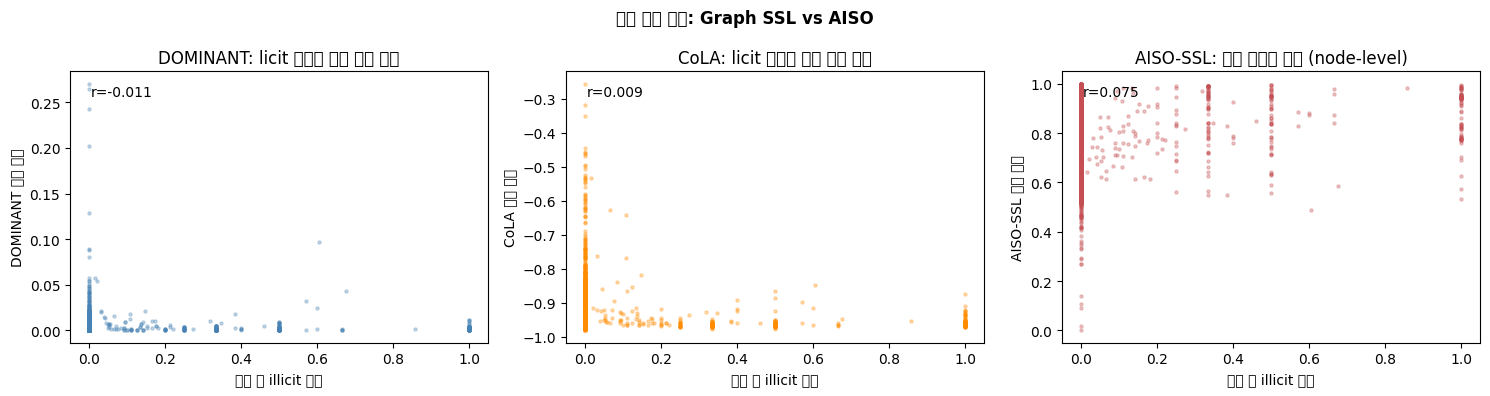

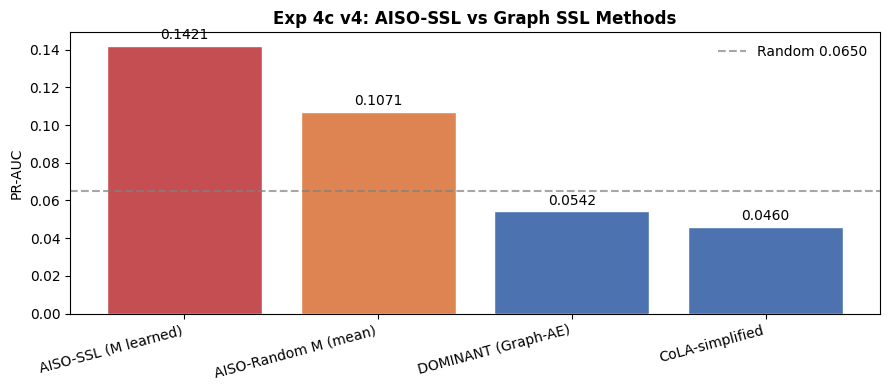

In [8]:
# 이웃 내 illicit 비율별 DOMINANT 점수 분포
illicit_neigh_ratios = []
for idx in test_idx:
    nbrs = adj_dict.get(idx, set())
    nbr_labels = [y_all[n] for n in nbrs if n < N_NODES]
    if len(nbr_labels) == 0:
        illicit_neigh_ratios.append(0.0)
    else:
        illicit_neigh_ratios.append(np.mean(nbr_labels))
illicit_neigh_ratios = np.array(illicit_neigh_ratios)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# DOMINANT 점수 vs 이웃 오염 비율 (licit 테스트 노드)
licit_te_mask = (y_te == 0)
ax = axes[0]
ax.scatter(illicit_neigh_ratios[licit_te_mask],
           dominant_sc[licit_te_mask],
           alpha=0.3, s=5, color='steelblue')
ax.set_xlabel('이웃 내 illicit 비율'); ax.set_ylabel('DOMINANT 이상 점수')
ax.set_title('DOMINANT: licit 노드의 이웃 오염 효과')
corr = np.corrcoef(illicit_neigh_ratios[licit_te_mask], dominant_sc[licit_te_mask])[0,1]
ax.text(0.05, 0.95, f'r={corr:.3f}', transform=ax.transAxes, va='top')

# CoLA 점수 vs 이웃 오염 비율 (licit 테스트 노드)
ax = axes[1]
ax.scatter(illicit_neigh_ratios[licit_te_mask],
           cola_sc[licit_te_mask],
           alpha=0.3, s=5, color='darkorange')
ax.set_xlabel('이웃 내 illicit 비율'); ax.set_ylabel('CoLA 이상 점수')
ax.set_title('CoLA: licit 노드의 이웃 오염 효과')
corr2 = np.corrcoef(illicit_neigh_ratios[licit_te_mask], cola_sc[licit_te_mask])[0,1]
ax.text(0.05, 0.95, f'r={corr2:.3f}', transform=ax.transAxes, va='top')

# AISO 점수 vs 이웃 오염 비율 (licit 테스트 노드) — 무관해야 함
ax = axes[2]
ax.scatter(illicit_neigh_ratios[licit_te_mask],
           aiso_ssl_sc[licit_te_mask],
           alpha=0.3, s=5, color='#C44E52')
ax.set_xlabel('이웃 내 illicit 비율'); ax.set_ylabel('AISO-SSL 이상 점수')
ax.set_title('AISO-SSL: 이웃 오염과 무관 (node-level)')
corr3 = np.corrcoef(illicit_neigh_ratios[licit_te_mask], aiso_ssl_sc[licit_te_mask])[0,1]
ax.text(0.05, 0.95, f'r={corr3:.3f}', transform=ax.transAxes, va='top')

plt.suptitle('이웃 오염 효과: Graph SSL vs AISO', fontweight='bold')
plt.tight_layout(); plt.show()

# PR-AUC 바차트
fig, ax = plt.subplots(figsize=(9, 4))
names = [nm for nm,_ in methods]
prs   = [res[nm][0] for nm in names]
cols  = ['#C44E52' if 'AISO-SSL' in nm else ('#DD8452' if 'AISO' in nm else '#4C72B0') for nm in names]
bars  = ax.bar(names, prs, color=cols, edgecolor='white')
ax.axhline(y_te.mean(), color='gray', linestyle='--', alpha=0.7, label=f'Random {y_te.mean():.4f}')
for bar, v in zip(bars, prs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{v:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('PR-AUC'); ax.set_title('Exp 4c v4: AISO-SSL vs Graph SSL Methods', fontweight='bold')
ax.legend(frameon=False); plt.tight_layout(); plt.show()
